In [1]:
import pandas as pd

df = pd.read_excel("../Data/Financial Sample.xlsx")

df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,NaN,1618.5,3,20,32370.0,0.0,32370.0,16185.0,16185.0,2014-01-01,1,January,2014
1,Government,Germany,Carretera,NaN,1321.0,3,20,26420.0,0.0,26420.0,13210.0,13210.0,2014-01-01,1,January,2014
2,Midmarket,France,Carretera,NaN,2178.0,3,15,32670.0,0.0,32670.0,21780.0,10890.0,2014-06-01,6,June,2014
3,Midmarket,Germany,Carretera,NaN,888.0,3,15,13320.0,0.0,13320.0,8880.0,4440.0,2014-06-01,6,June,2014
4,Midmarket,Mexico,Carretera,NaN,2470.0,3,15,37050.0,0.0,37050.0,24700.0,12350.0,2014-06-01,6,June,2014


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (700, 16)

Columns:
['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']

Missing values:
Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
 Sales                  0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64


In [3]:
df[df["Discount Band"].isna()][
    ["Segment", "Country", "Product", "Units Sold", "Sales", "Profit"]
].head(20)

KeyError: "['Sales'] not in index"

In [4]:
print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', ' Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [5]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold', 'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name', 'Year']


In [6]:
df[df["Discount Band"].isna()][
    ["Segment", "Country", "Product", "Units Sold", "Sales", "Profit"]
].head(20)

,Segment,Country,Product,Units Sold,Sales,Profit
0,Government,Canada,Carretera,1618.5,32370.0,16185.0
1,Government,Germany,Carretera,1321.0,26420.0,13210.0
2,Midmarket,France,Carretera,2178.0,32670.0,10890.0
3,Midmarket,Germany,Carretera,888.0,13320.0,4440.0
4,Midmarket,Mexico,Carretera,2470.0,37050.0,12350.0
5,Government,Germany,Carretera,1513.0,529550.0,136170.0
6,Midmarket,Germany,Montana,921.0,13815.0,4605.0
7,Channel Partners,Canada,Montana,2518.0,30216.0,22662.0
8,Government,France,Montana,1899.0,37980.0,18990.0
9,Channel Partners,Germany,Montana,1545.0,18540.0,13905.0


In [7]:
df_clean = df.copy()

df_clean["Discount Band"] = df_clean["Discount Band"].fillna("Unknown")

print(df_clean["Discount Band"].value_counts())

Discount Band
High       245
Medium     242
Low        160
Unknown     53
Name: count, dtype: int64


In [8]:
print("Date range:")
print(df_clean["Date"].min(), "to", df_clean["Date"].max())

print("\nData types:")
print(df_clean.dtypes)

Date range:
2013-09-01 00:00:00 to 2014-12-01 00:00:00

Data types:
Segment                           str
Country                           str
Product                           str
Discount Band                     str
Units Sold                    float64
Manufacturing Price             int64
Sale Price                      int64
Gross Sales                   float64
Discounts                     float64
Sales                         float64
COGS                          float64
Profit                        float64
Date                   datetime64[us]
Month Number                    int64
Month Name                        str
Year                            int64
dtype: object


In [9]:
print(df_clean["Date"].min())
print(df_clean["Date"].max())

2013-09-01 00:00:00
2014-12-01 00:00:00


In [10]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_cogs = df_clean["COGS"].sum()
total_units = df_clean["Units Sold"].sum()

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total COGS: ${total_cogs:,.2f}")
print(f"Total Units Sold: {total_units:,.0f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $118,726,350.26
Total Profit: $16,893,702.26
Total COGS: $101,832,648.00
Total Units Sold: 1,125,806
Profit Margin: 14.23%


In [11]:
yearly_performance = (
    df_clean.groupby("Year")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        COGS=("COGS", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
)

yearly_performance["Profit_Margin_%"] = (
    yearly_performance["Profit"] /
    yearly_performance["Sales"] * 100
)

yearly_performance

,Year,Sales,Profit,COGS,Units_Sold,Profit_Margin_%
0,2013,26415255.51,3878464.51,22536791.0,264674.0,14.682669
1,2014,92311094.75,13015237.75,79295857.0,861132.0,14.099321


In [12]:
country_performance = (
    df_clean.groupby("Country")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
)

country_performance["Profit_Margin_%"] = (
    country_performance["Profit"] /
    country_performance["Sales"] * 100
)

country_performance = country_performance.sort_values(
    "Sales", ascending=False
)

country_performance

,Country,Sales,Profit,Units_Sold,Profit_Margin_%
4,United States of America,2.502983e+07,2995540.665,232627.5,11.967883
0,Canada,2.488765e+07,3529228.885,247428.5,14.180641
1,France,2.435417e+07,3781020.780,240931.0,15.525146
2,Germany,2.350534e+07,3680388.820,201494.0,15.657671
3,Mexico,2.094935e+07,2907523.110,203325.0,13.878821


In [13]:
product_performance = (
    df_clean.groupby("Product")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
)

product_performance["Profit_Margin_%"] = (
    product_performance["Profit"] /
    product_performance["Sales"] * 100
)

product_performance = product_performance.sort_values(
    "Sales", ascending=False
)

product_performance

,Product,Sales,Profit,Units_Sold,Profit_Margin_%
3,Paseo,3.301114e+07,4797437.950,338239.5,14.532783
4,VTT,2.051192e+07,3034608.020,168783.0,14.794363
5,Velo,1.825006e+07,2305992.465,162424.5,12.635534
0,Amarilla,1.774712e+07,2814104.060,155315.0,15.856684
2,Montana,1.539080e+07,2114754.880,154198.0,13.740381
1,Carretera,1.381531e+07,1826804.885,146846.0,13.223049


In [14]:
segment_performance = (
    df_clean.groupby("Segment")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
)

segment_performance["Profit_Margin_%"] = (
    segment_performance["Profit"] /
    segment_performance["Sales"] * 100
)

segment_performance = segment_performance.sort_values(
    "Sales", ascending=False
)

segment_performance

,Segment,Sales,Profit,Units_Sold,Profit_Margin_%
2,Government,5.250426e+07,1.138817e+07,470673.5,21.689998
4,Small Business,4.242792e+07,4.143168e+06,153139.0,9.765194
1,Enterprise,1.961169e+07,-6.145456e+05,168552.0,-3.133567
3,Midmarket,2.381883e+06,6.601031e+05,172178.0,27.713496
0,Channel Partners,1.800594e+06,1.316803e+06,161263.5,73.131611


In [15]:
monthly_performance = (
    df_clean.groupby("Date")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        COGS=("COGS", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
    .sort_values("Date")
)

monthly_performance["Profit_Margin_%"] = (
    monthly_performance["Profit"] /
    monthly_performance["Sales"] * 100
)

monthly_performance.head(10)

,Date,Sales,Profit,COGS,Units_Sold,Profit_Margin_%
0,2013-09-01,4484000.03,763603.03,3720397.0,50601.0,17.029505
1,2013-10-01,9295611.10,1657795.10,7637816.0,95622.0,17.834170
2,2013-11-01,7267203.30,765502.30,6501701.0,65481.0,10.533657
3,2013-12-01,5368441.08,691564.08,4676877.0,52970.0,12.882028
4,2014-01-01,6607761.68,814028.68,5793733.0,67835.5,12.319280
5,2014-02-01,7297531.39,1148547.39,6148984.0,55115.0,15.738848
6,2014-03-01,5586859.87,669866.87,4916993.0,53420.0,11.990042
7,2014-04-01,6964775.07,929984.57,6034790.5,78886.5,13.352686
8,2014-05-01,6210211.06,828640.06,5381571.0,51771.0,13.343187
9,2014-06-01,9518893.82,1473753.82,8045140.0,103302.0,15.482406


In [16]:
best_month = monthly_performance.loc[
    monthly_performance["Sales"].idxmax()
]

worst_month = monthly_performance.loc[
    monthly_performance["Sales"].idxmin()
]

print("Highest Sales Month:")
print(best_month)

print("\nLowest Sales Month:")
print(worst_month)

Highest Sales Month:
Date               2014-10-01 00:00:00
Sales                      12375819.92
Profit                      1781985.92
COGS                        10593834.0
Units_Sold                    105482.0
Profit_Margin_%              14.398932
Name: 13, dtype: object

Lowest Sales Month:
Date               2013-09-01 00:00:00
Sales                       4484000.03
Profit                       763603.03
COGS                         3720397.0
Units_Sold                     50601.0
Profit_Margin_%              17.029505
Name: 0, dtype: object


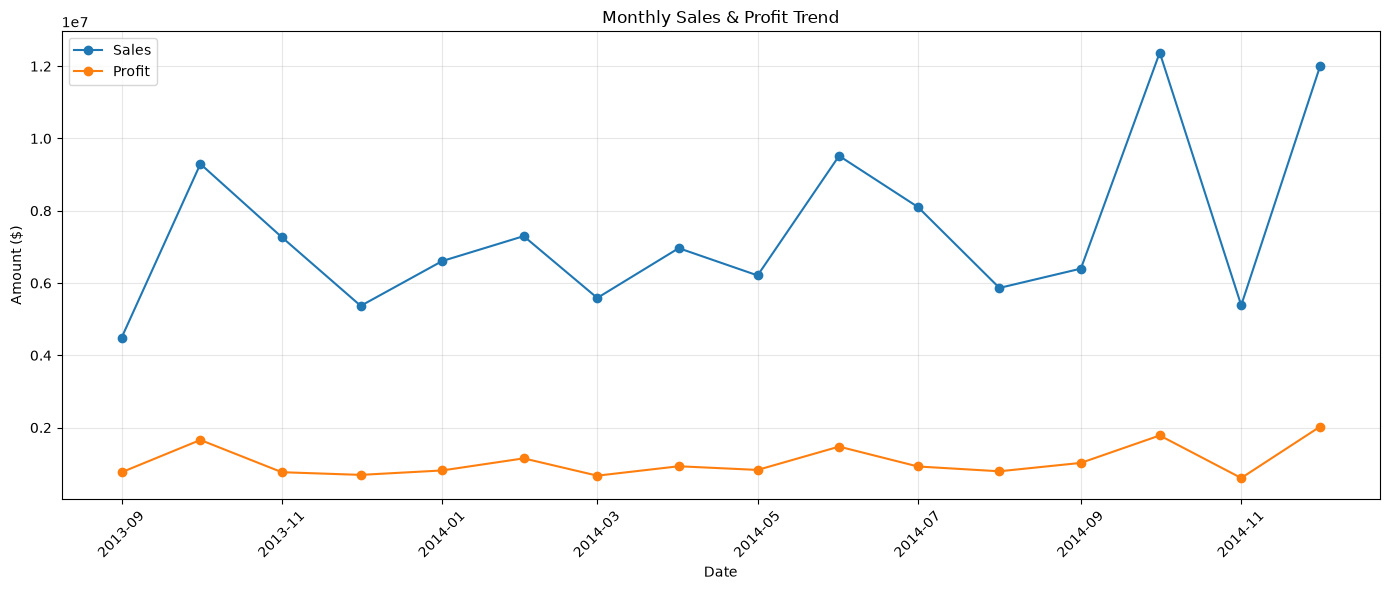

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_performance["Date"],
    monthly_performance["Sales"],
    marker="o",
    label="Sales"
)

plt.plot(
    monthly_performance["Date"],
    monthly_performance["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Sales & Profit Trend")
plt.xlabel("Date")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
discount_performance = (
    df_clean.groupby("Discount Band")
    .agg(
        Sales=("Sales", "sum"),
        Discounts=("Discounts", "sum"),
        Profit=("Profit", "sum"),
        Units_Sold=("Units Sold", "sum")
    )
    .reset_index()
)

discount_performance["Profit_Margin_%"] = (
    discount_performance["Profit"] /
    discount_performance["Sales"] * 100
)

discount_performance.sort_values("Discounts")

,Discount Band,Sales,Discounts,Profit,Units_Sold,Profit_Margin_%
3,Unknown,7.943654e+06,0.000,1736455.000,86163.5,21.859650
1,Low,3.462978e+07,885675.800,6188857.700,261858.5,17.871491
2,Medium,3.878043e+07,3002546.165,5579522.835,379698.5,14.387470
0,High,3.737249e+07,5317026.275,3388866.725,398085.5,9.067812


In [19]:
df_clean["Discount_Rate_%"] = (
    df_clean["Discounts"] / df_clean["Gross Sales"] * 100
)

discount_rate_summary = (
    df_clean.groupby("Discount Band")
    .agg(
        Gross_Sales=("Gross Sales", "sum"),
        Discounts=("Discounts", "sum"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

discount_rate_summary["Discount_Rate_%"] = (
    discount_rate_summary["Discounts"] /
    discount_rate_summary["Gross_Sales"] * 100
)

discount_rate_summary["Profit_Margin_%"] = (
    discount_rate_summary["Profit"] /
    discount_rate_summary["Sales"] * 100
)

discount_rate_summary

,Discount Band,Gross_Sales,Discounts,Sales,Profit,Discount_Rate_%,Profit_Margin_%
0,High,42689513.0,5317026.275,3.737249e+07,3388866.725,12.455111,9.067812
1,Low,35515454.5,885675.800,3.462978e+07,6188857.700,2.493776,17.871491
2,Medium,41782977.0,3002546.165,3.878043e+07,5579522.835,7.186051,14.387470
3,Unknown,7943654.0,0.000,7.943654e+06,1736455.000,0.000000,21.859650


In [20]:
df_clean.to_csv(
    "../PowerBI/financial_performance_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully.")
print(df_clean.shape)

Cleaned dataset exported successfully.
(700, 17)
